In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import seaborn as sns

import pickle


In [2]:
GROUP1 = pd.read_csv("../data/FOOD-DATA-GROUP1.csv")
GROUP2 = pd.read_csv("../data/FOOD-DATA-GROUP2.csv")
GROUP3 = pd.read_csv("../data/FOOD-DATA-GROUP3.csv")
GROUP4 = pd.read_csv("../data/FOOD-DATA-GROUP4.csv")
GROUP5 = pd.read_csv("../data/FOOD-DATA-GROUP5.csv")

In [3]:
data = pd.concat([
    GROUP1,
     GROUP2,
     GROUP3,
     GROUP4,
     GROUP5
])

data.reset_index(
    drop=True,
    inplace=True
)

In [4]:
print(data.shape)

data.head()


(2395, 37)


,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,0,0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,...,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,1,1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,...,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,2,2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,3,3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,...,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,4,4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,...,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


In [5]:
numeric_columns = [
    "Caloric Value",
    "Fat",
    "Carbohydrates",
    "Sugars",
    "Protein",
    "Dietary Fiber",
    "Nutrition Density"
]

In [6]:
for col in numeric_columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

In [7]:
data = data.fillna(0)

In [8]:
data["Target"] = (
    (data["Sugars"] <= 20) &
    (data["Fat"] <= 20)
).astype(int)

In [9]:
print(
    data["Target"].value_counts()
)


Target
1    1999
0     396
Name: count, dtype: int64


In [10]:
features = [
    "Caloric Value",
    "Fat",
    "Carbohydrates",
    "Sugars",
    "Protein",
    "Dietary Fiber",
    "Nutrition Density"
]

X = data[features]

y = data["Target"]

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [13]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
y_pred = knn_model.predict(
    X_test_scaled
)


In [15]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "KNN Accuracy:",
    accuracy
)


KNN Accuracy: 0.9749478079331941


In [16]:
print(
    classification_report(
        y_test,
        y_pred
    )
)


              precision    recall  f1-score   support

           0       0.92      0.89      0.90        62
           1       0.98      0.99      0.99       417

    accuracy                           0.97       479
   macro avg       0.95      0.94      0.94       479
weighted avg       0.97      0.97      0.97       479



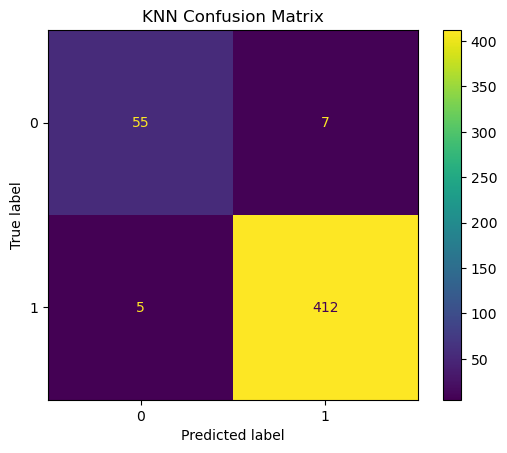

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("KNN Confusion Matrix")

plt.show()


In [18]:

k_values = []

accuracies = []

for k in range(1, 21):

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(
        X_train_scaled,
        y_train
    )

    pred = knn.predict(
        X_test_scaled
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    k_values.append(k)

    accuracies.append(acc)



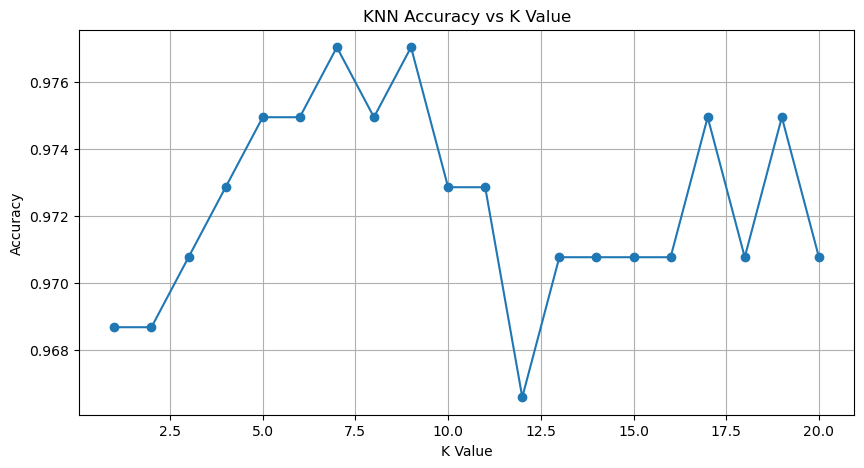

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    k_values,
    accuracies,
    marker='o'
)

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("KNN Accuracy vs K Value")

plt.grid(True)

plt.show()


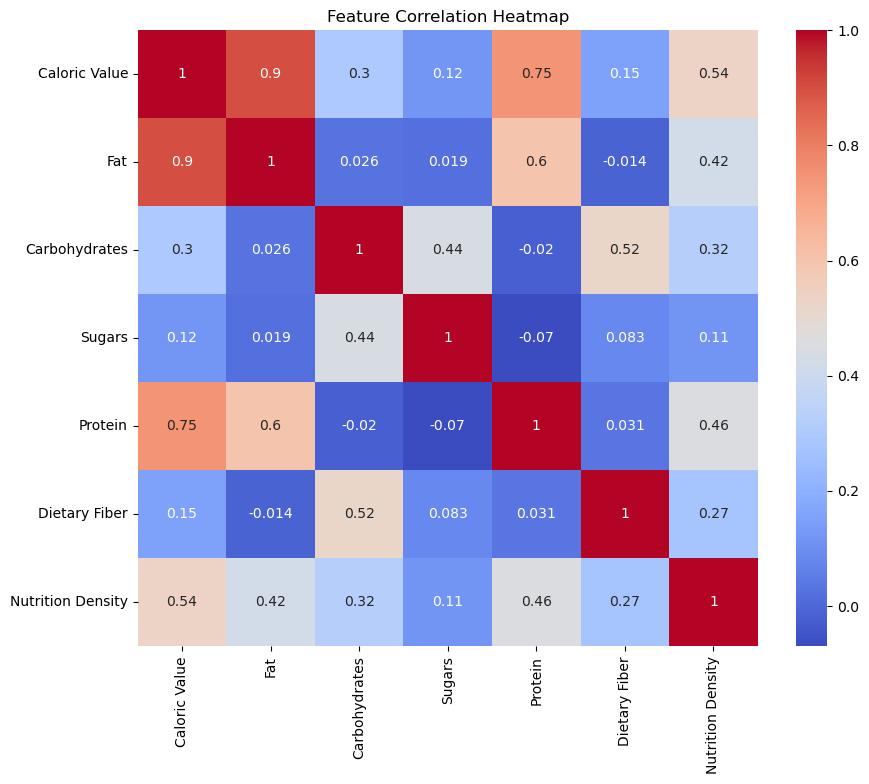

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data[features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.show()


In [21]:
pickle.dump(
    knn_model,
    open(
        "knn_model.pkl",
        "wb"
    )
)

In [22]:
pickle.dump(
    scaler,
    open(
        "knn_scaler.pkl",
        "wb"
    )
)

In [23]:
print("KNN Model Saved Successfully")

KNN Model Saved Successfully


###### 